# Rental Price Intelligence — Exploratory Data Analysis (EDA)



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/rentals_model_ready.csv')   
print(f'{df.shape[0]} rows x {df.shape[1]} cols')
df.head()

5015 rows x 21 cols


,property_type,locality,furnishing,facing,rent,bhk,carpet_area,floor_num,total_floors,floor_ratio,available_immediately,overlooks_garden,overlooks_pool,overlooks_main_road,metro_mins,has_metro,near_school,near_hospital,near_mall,near_bus,near_railway
0,flat,andheri-east,Furnished,East,83000.0,2.0,911.0,4.0,10.0,0.400000,1,1,1,1,5.0,1,1,1,1,1,0
1,flat,andheri-east,Semi-Furnished,Unknown,25000.0,1.0,300.0,4.0,7.0,0.571429,0,0,0,0,30.0,0,1,1,1,1,0
2,flat,andheri-east,Unfurnished,North - East,54000.0,2.0,660.0,5.0,10.0,0.500000,1,1,0,0,30.0,0,1,1,1,1,0
3,flat,andheri-east,Semi-Furnished,East,130000.0,3.0,1270.0,7.0,12.0,0.583333,1,1,0,1,5.0,1,1,1,1,0,1
4,flat,andheri-east,Furnished,East,35000.0,1.0,415.0,3.0,7.0,0.428571,1,1,0,0,5.0,1,1,1,1,0,0


In [3]:
# Define feature groups up front — used throughout the notebook.
target = 'rent'

numeric_feats = ['carpet_area','bhk','floor_num','total_floors','floor_ratio','metro_mins']
binary_feats  = ['available_immediately','has_metro','overlooks_garden','overlooks_pool',
                 'overlooks_main_road','near_school','near_hospital','near_mall','near_bus','near_railway']
cat_feats     = ['property_type','locality','facing']
ordinal_feats = ['furnishing_ord']

print('Numeric :', numeric_feats)
print('Binary  :', binary_feats)
print('Categorical:', cat_feats)
print('Ordinal :', ordinal_feats)

Numeric : ['carpet_area', 'bhk', 'floor_num', 'total_floors', 'floor_ratio', 'metro_mins']
Binary  : ['available_immediately', 'has_metro', 'overlooks_garden', 'overlooks_pool', 'overlooks_main_road', 'near_school', 'near_hospital', 'near_mall', 'near_bus', 'near_railway']
Categorical: ['property_type', 'locality', 'facing']
Ordinal : ['furnishing_ord']


---
# 1. Univariate Analysis


## 1.1 Target — `rent`

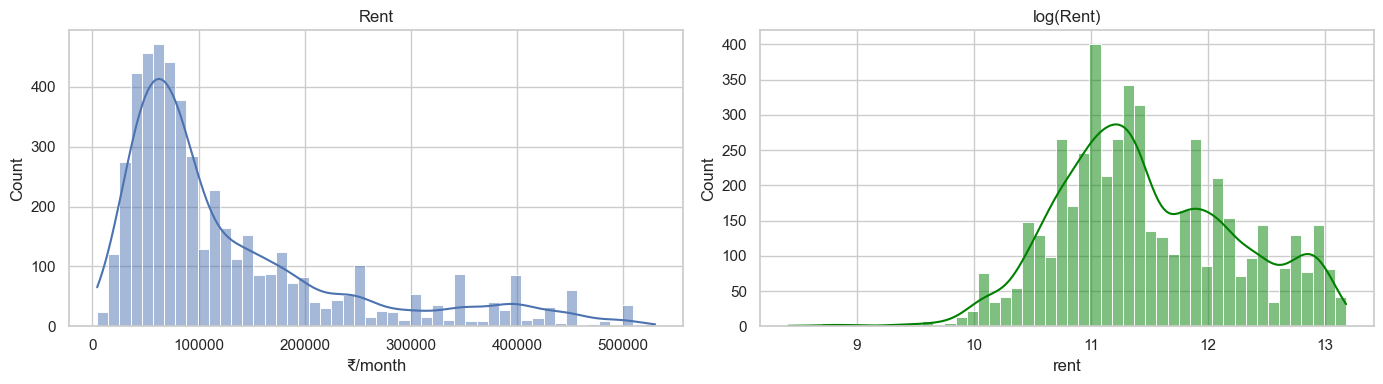

Skewness raw : 1.57
Skewness log : 0.2
count      5015.000000
mean     130313.142772
std      109577.349837
min        4500.000000
25%       56000.000000
50%       85000.000000
75%      170000.000000
max      530000.000000
Name: rent, dtype: float64


In [4]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
sns.histplot(df['rent'], bins=50, kde=True, ax=ax[0]); ax[0].set_title('Rent'); ax[0].set_xlabel('₹/month')
sns.histplot(np.log1p(df['rent']), bins=50, kde=True, color='green', ax=ax[1]); ax[1].set_title('log(Rent)')
plt.tight_layout(); plt.show()
print('Skewness raw :', round(df['rent'].skew(),2))
print('Skewness log :', round(np.log1p(df['rent']).skew(),2))
print(df['rent'].describe())

**Takeaway:** rent is strongly right-skewed (skew >> 1). The log version is far more symmetric → the model target should be `log(rent)` (applied in the modelling pipeline). Median ≈ ₹85k.

## 1.2 Numeric features — distributions & skew

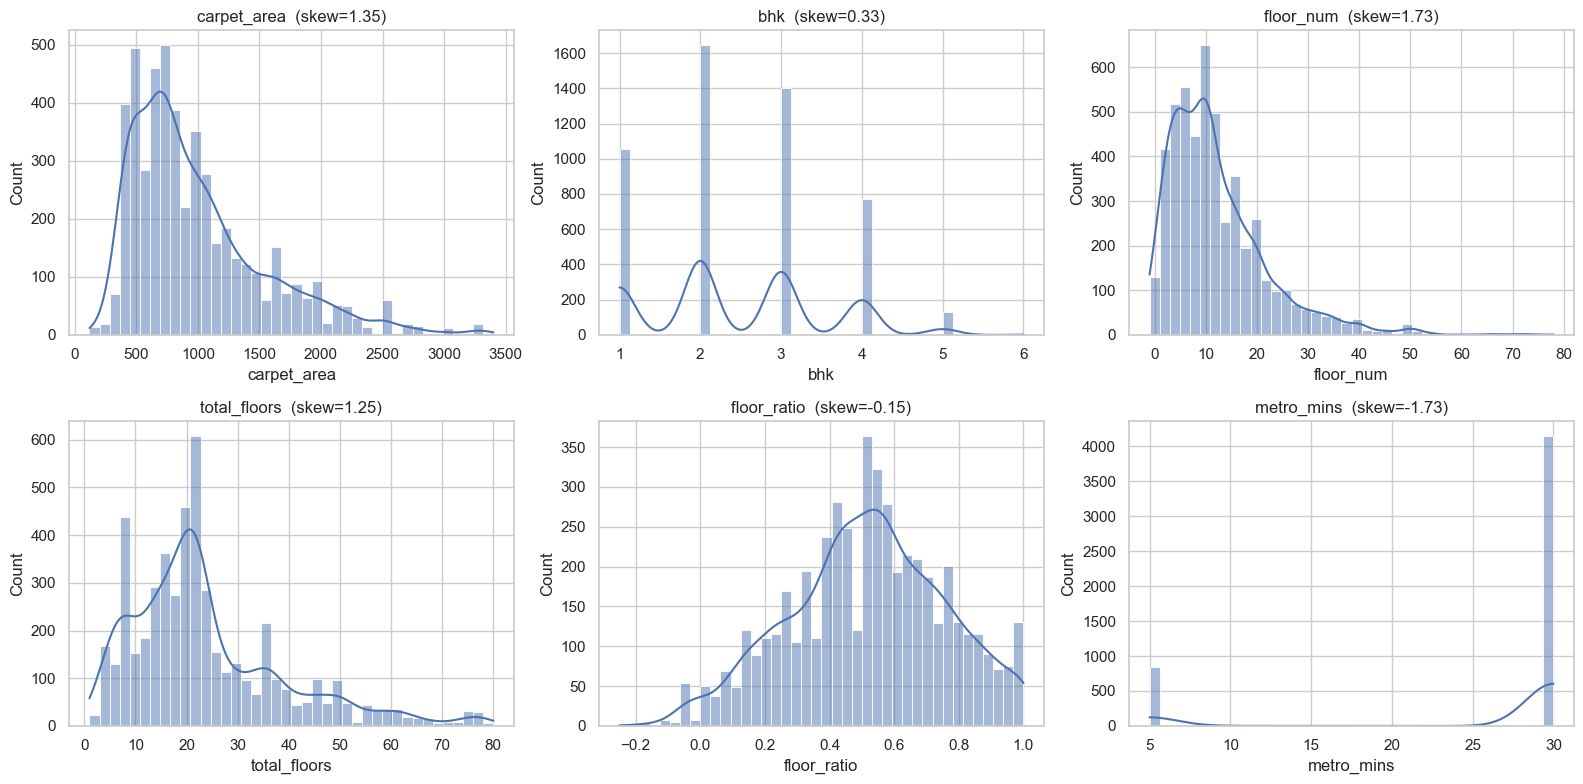

Skewness (|skew|>1 suggests transform):
floor_num       1.73
carpet_area     1.35
total_floors    1.25
bhk             0.33
floor_ratio    -0.15
metro_mins     -1.73
dtype: float64


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), numeric_feats):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'{col}  (skew={df[col].skew():.2f})')
plt.tight_layout(); plt.show()

# Numeric skew summary
skews = df[numeric_feats].skew().sort_values(ascending=False)
print('Skewness (|skew|>1 suggests transform):')
print(skews.round(2))

**Takeaway (interpret from output):**
- `carpet_area` is likely right-skewed → consider log/transform at modelling.
- `bhk`, `floor_num`, `total_floors` — moderate; usually fine as-is.
- `floor_ratio` — bounded 0–1 (with a few negative basements), roughly uniform.
- `metro_mins` — note it's capped at the 'far' fill value for un-reported rows; `has_metro` carries that.
- Flag any feature with |skew| > 1 for transformation.

## 1.3 Categorical features — class balance

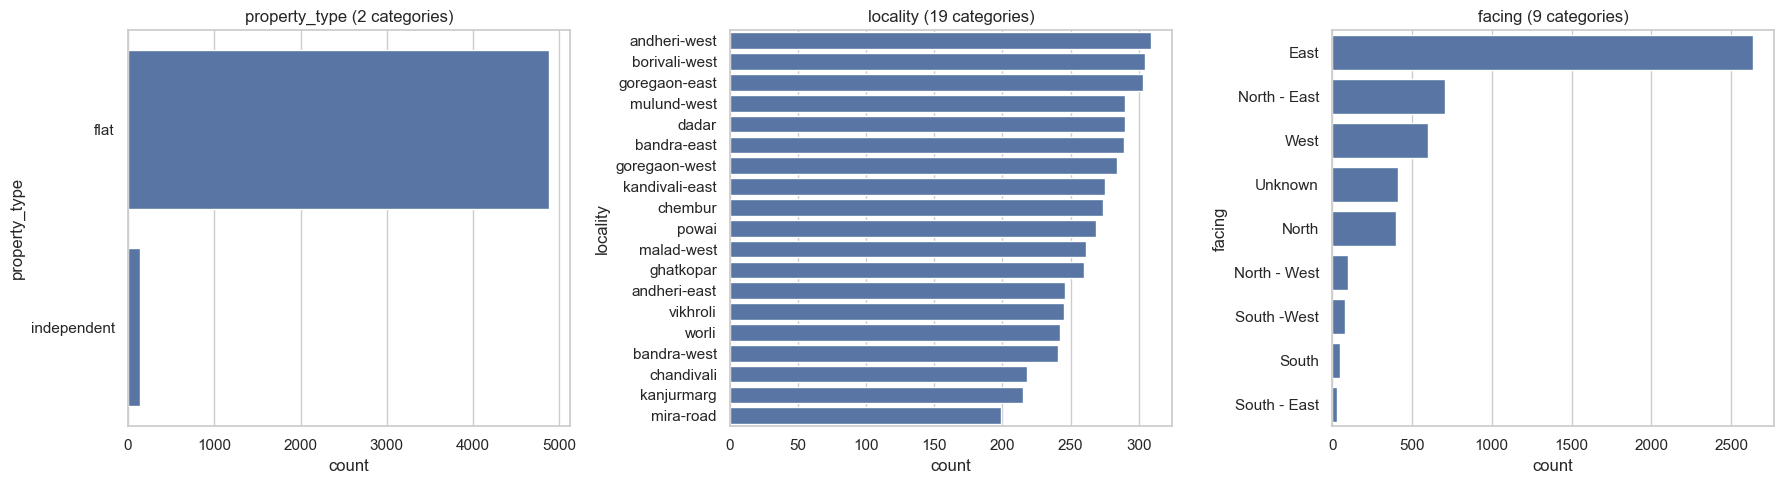


property_type:
property_type
flat           4878
independent     137
Name: count, dtype: int64

locality:
locality
andheri-west      309
borivali-west     305
goregaon-east     303
mulund-west       290
dadar             290
bandra-east       289
goregaon-west     284
kandivali-east    275
chembur           274
powai             269
malad-west        261
ghatkopar         260
andheri-east      246
vikhroli          245
worli             242
bandra-west       241
chandivali        218
kanjurmarg        215
mira-road         199
Name: count, dtype: int64

facing:
facing
East            2636
North - East     708
West             599
Unknown          414
North            400
North - West      97
South -West       78
South             52
South - East      31
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_feats):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f'{col} ({df[col].nunique()} categories)')
plt.tight_layout(); plt.show()

for col in cat_feats:
    print(f'\n{col}:'); print(df[col].value_counts())

**Takeaway (interpret from output):**
- `property_type` — heavily flat-dominated (independent is small but retained as a signal).
- `locality` — 19 fairly balanced categories → good for one-hot later.
- `facing` — East-dominated with an 'Unknown' bucket; weak predictor.

## 1.4 Binary & ordinal features — balance check

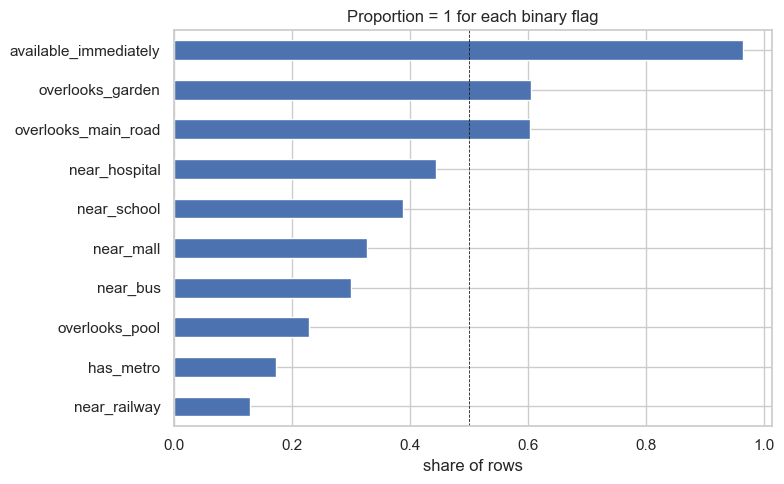

near_railway             0.130
has_metro                0.174
overlooks_pool           0.229
near_bus                 0.301
near_mall                0.328
near_school              0.388
near_hospital            0.444
overlooks_main_road      0.604
overlooks_garden         0.606
available_immediately    0.966
dtype: float64

furnishing_ord distribution:
furnishing
Furnished         1155
Semi-Furnished    2400
Unfurnished       1460
Name: count, dtype: int64


In [8]:
# Proportion of 1s for each binary — a flag that's ~0% or ~100% carries little signal
prop = df[binary_feats].mean().sort_values()
prop.plot(kind='barh', figsize=(8,5)); plt.title('Proportion = 1 for each binary flag')
plt.xlabel('share of rows'); plt.axvline(0.5, color='k', lw=.6, ls='--'); plt.tight_layout(); plt.show()
print(prop.round(3))
print('\nfurnishing_ord distribution:'); print(df['furnishing'].value_counts().sort_index())

**Takeaway:** flags with a proportion very close to 0 or 1 have little variance and may be droppable (little to learn from). Balanced flags (~near 0.5) are the most informative. 

---
# 2. Outlier Inspection (all numeric features)


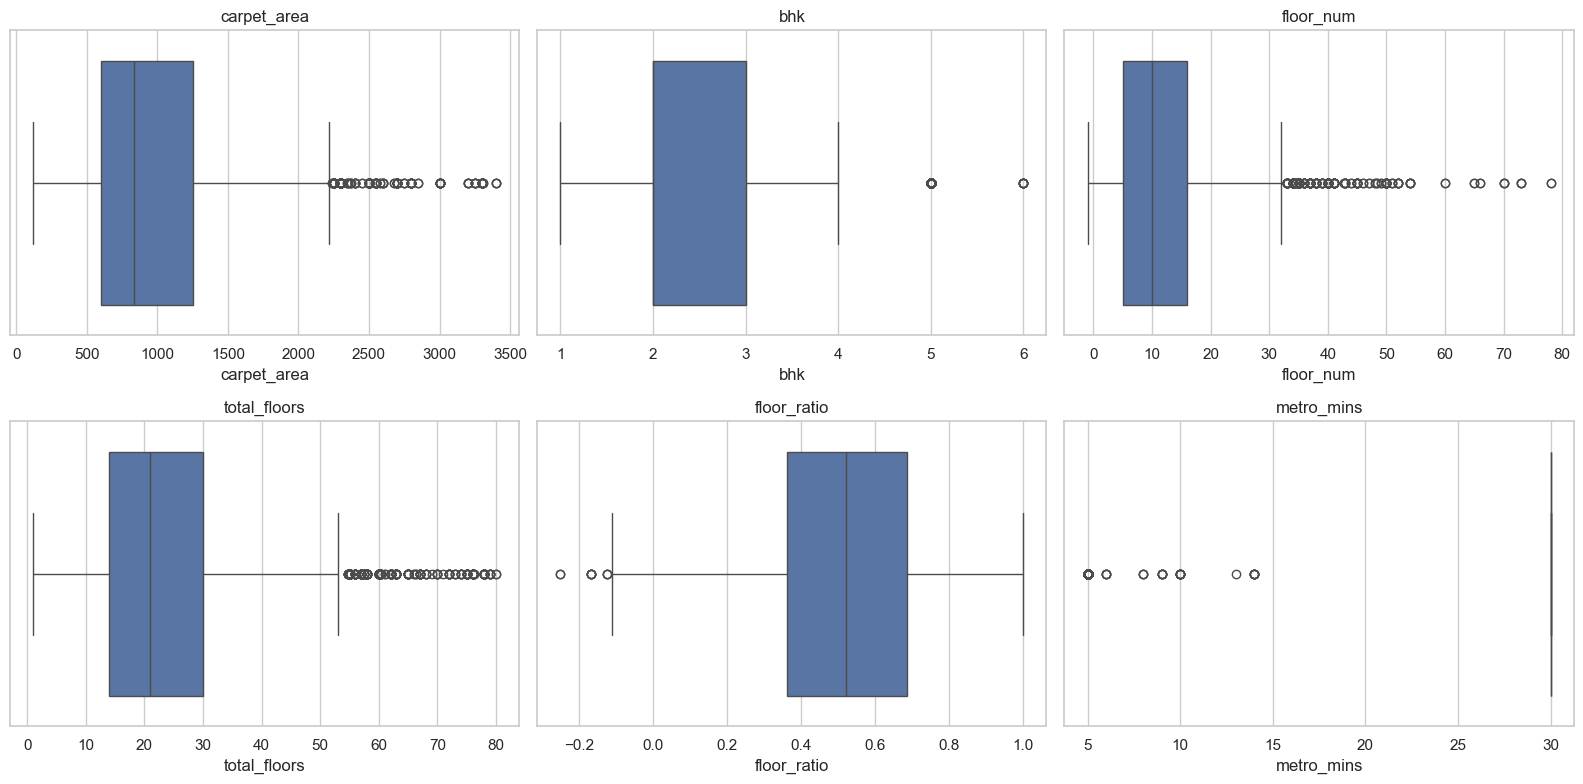

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), numeric_feats):
    sns.boxplot(x=df[col], ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

In [10]:
# Quantify outliers via IQR for each numeric — how many, and are they plausible?
print('IQR-based outlier counts (inspect, do not auto-delete):\n')
for col in numeric_feats:
    q1,q3 = df[col].quantile(.25), df[col].quantile(.75); iqr=q3-q1
    lo,hi = q1-1.5*iqr, q3+1.5*iqr
    n = ((df[col]<lo)|(df[col]>hi)).sum()
    print(f'{col:14s}: {n:4d} outliers  | range kept [{lo:.1f}, {hi:.1f}]  | actual max {df[col].max():.0f}')

IQR-based outlier counts (inspect, do not auto-delete):

carpet_area   :  196 outliers  | range kept [-375.0, 2225.0]  | actual max 3400
bhk           :  137 outliers  | range kept [0.5, 4.5]  | actual max 6
floor_num     :  234 outliers  | range kept [-11.5, 32.5]  | actual max 78
total_floors  :  290 outliers  | range kept [-10.0, 54.0]  | actual max 80
floor_ratio   :   10 outliers  | range kept [-0.1, 1.2]  | actual max 1
metro_mins    :  869 outliers  | range kept [30.0, 30.0]  | actual max 30


**Takeaway (interpret from output):**
- rent & carpet_area were already IQR-trimmed in cleaning, so few extreme values remain.
- For bhk/floor/total_floors: high values are usually *real* (large flats, tall towers) → **keep**.
- Only remove a value if it's physically impossible (e.g. area = 5 sqft, floor > total_floors). Check for those specifically below.

In [22]:
# Specific impossibility checks
print('floor_num > total_floors (impossible):',
      ((df['floor_num'] > df['total_floors']) & df['total_floors'].notna()).sum())
print('carpet_area < 100 sqft (implausibly tiny):', (df['carpet_area'] < 100).sum())
print('rent < 5000 (implausibly low for Mumbai):', (df['rent'] < 5000).sum())

floor_num > total_floors (impossible): 0
carpet_area < 100 sqft (implausibly tiny): 0
rent < 5000 (implausibly low for Mumbai): 2


**Decision:** need to remove only rows failing these impossibility checks . Everything else stays — extreme-but-real values are valuable for a model that must handle the luxury tail.

In [23]:
df = df[df["rent"] >= 5000].reset_index(drop=True)

---
# 3. Bivariate Analysis


## 3.1 Numeric features vs rent (scatter + correlation)

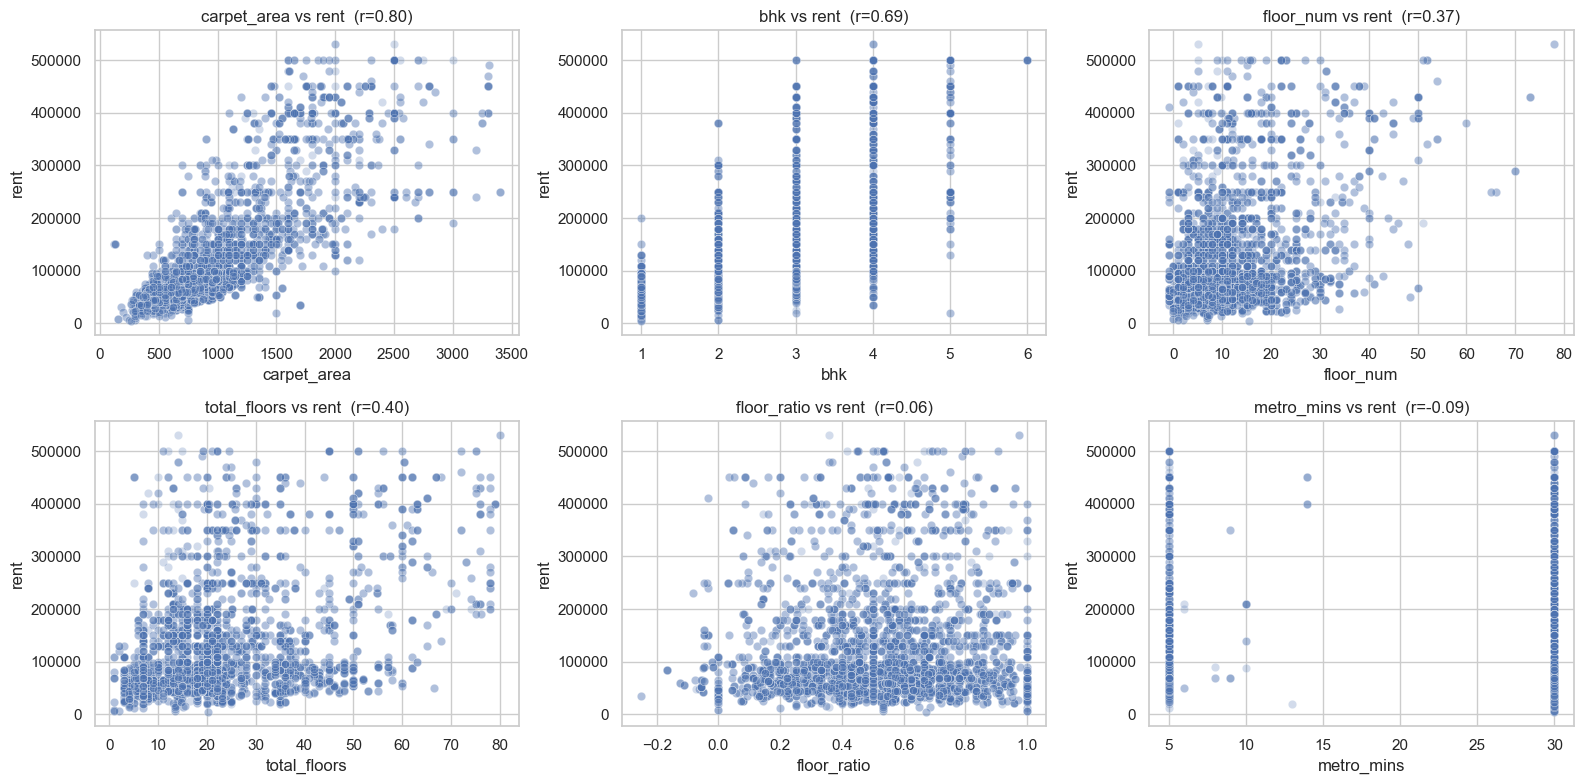

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), numeric_feats):
    sns.scatterplot(data=df, x=col, y='rent', alpha=0.25, ax=ax)
    r = df[[col,'rent']].corr().iloc[0,1]
    ax.set_title(f'{col} vs rent  (r={r:.2f})')
plt.tight_layout(); plt.show()

**Takeaway (interpret from output):** the features with the steepest relationship / highest |r| with rent are strongest predictors (expect carpet_area and bhk to lead). Near-flat clouds (r≈0) indicate weak predictors — candidates to drop if they add nothing.

## 3.2 Categorical / ordinal features vs rent (boxplots)

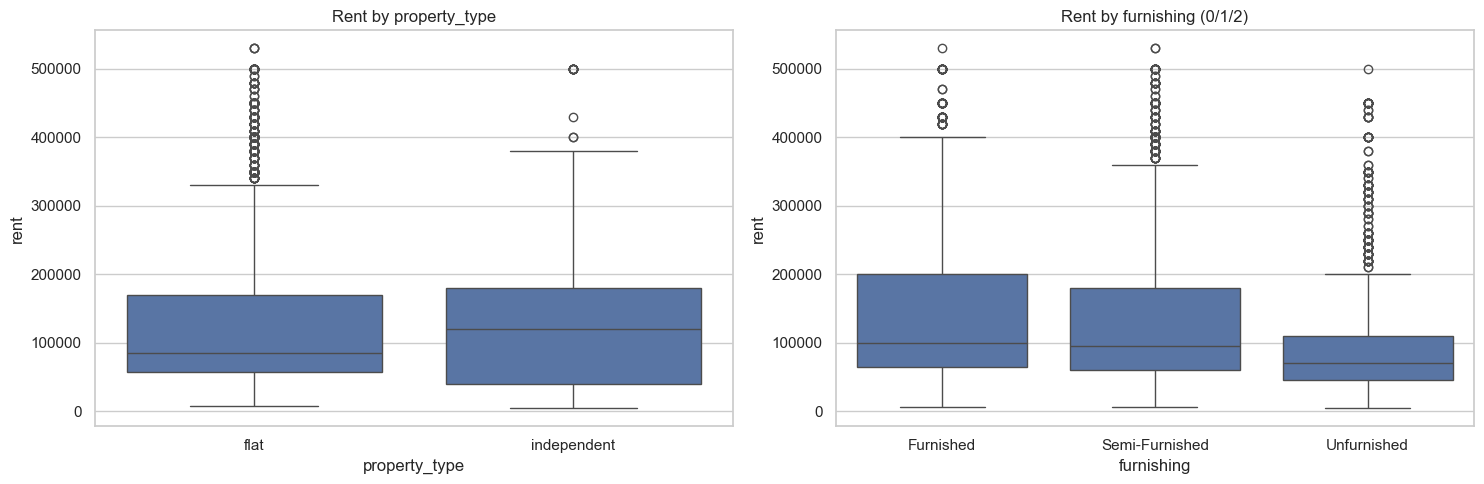

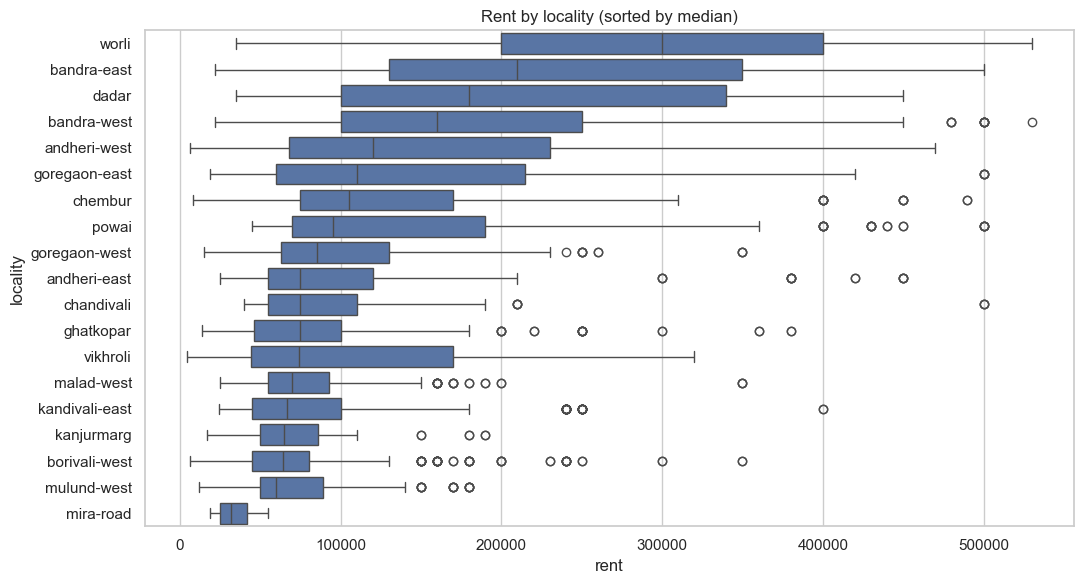

In [14]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(data=df, x='property_type', y='rent', ax=ax[0]); ax[0].set_title('Rent by property_type')
sns.boxplot(data=df, x='furnishing', y='rent', ax=ax[1]); ax[1].set_title('Rent by furnishing (0/1/2)')
plt.tight_layout(); plt.show()

# Locality — the market map
order = df.groupby('locality')['rent'].median().sort_values(ascending=False).index
plt.figure(figsize=(11,6))
sns.boxplot(data=df, y='locality', x='rent', order=order)
plt.title('Rent by locality (sorted by median)'); plt.tight_layout(); plt.show()

**Takeaway:** locality clearly separates rent (the market map) → strong categorical predictor. Furnishing shows a monotonic premium → keep as ordinal. property_type: check whether independent vs flat meaningfully differ.

## 3.3 Binary flags vs rent (does each flag move rent?)

                 flag  median_if_1  median_if_0  uplift_%
       overlooks_pool     130000.0      79000.0      64.6
  overlooks_main_road      90000.0      78500.0      14.6
     overlooks_garden      90000.0      80000.0      12.5
        near_hospital      90000.0      80000.0      12.5
         near_railway      95000.0      85000.0      11.8
            has_metro      95000.0      85000.0      11.8
             near_bus      90000.0      85000.0       5.9
            near_mall      90000.0      85000.0       5.9
          near_school      85000.0      85000.0       0.0
available_immediately      85000.0     100000.0     -15.0


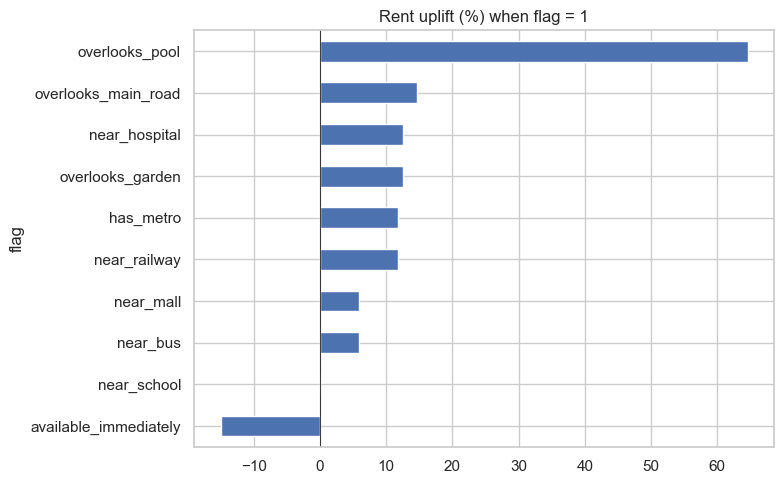

In [15]:
rows = []
base = df['rent'].median()
for f in binary_feats:
    med1 = df.loc[df[f]==1,'rent'].median()
    med0 = df.loc[df[f]==0,'rent'].median()
    rows.append({'flag':f, 'median_if_1':med1, 'median_if_0':med0,
                 'uplift_%': round((med1/med0-1)*100,1) if med0 else np.nan})
uplift = pd.DataFrame(rows).sort_values('uplift_%', ascending=False)
print(uplift.to_string(index=False))
uplift.set_index('flag')['uplift_%'].sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Rent uplift (%) when flag = 1'); plt.axvline(0,color='k',lw=.6); plt.tight_layout(); plt.show()

**Takeaway:** flags with a large positive uplift (e.g. pool view, near-mall) are useful features; flags near 0% uplift add little and could be dropped. This gives an evidence-based keep/drop list for the binary features.

## 3.4 Correlation heatmap — redundancy & multicollinearity

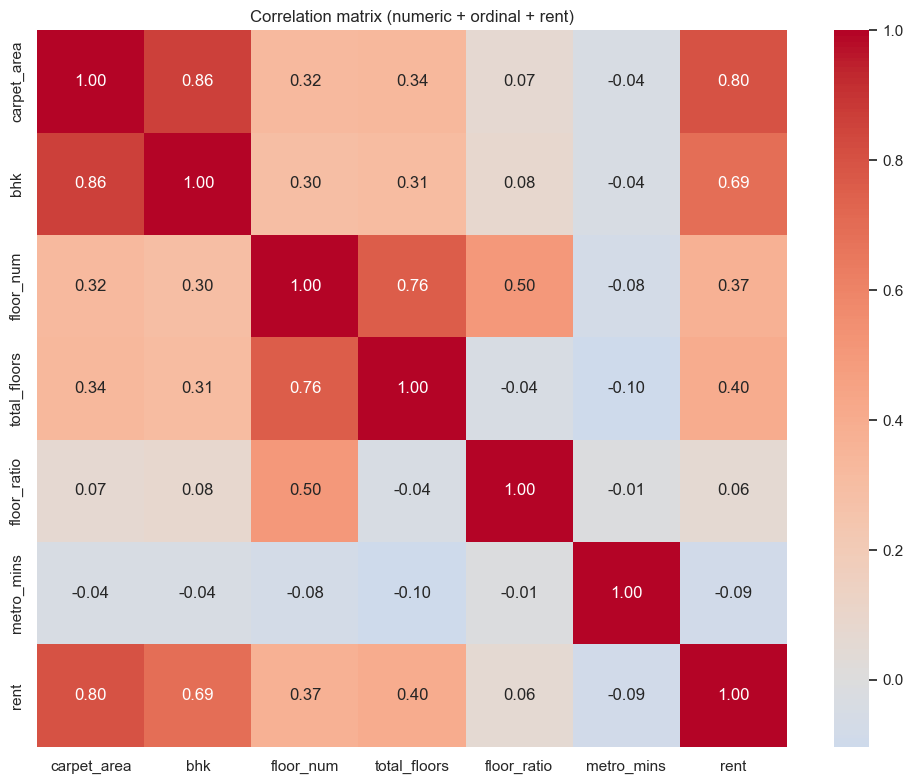

In [18]:
num_all = numeric_feats  + ['rent']
plt.figure(figsize=(10,8))
sns.heatmap(df[num_all].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (numeric + ordinal + rent)'); plt.tight_layout(); plt.show()

**Takeaway (interpret from output):**
- Read the `rent` row for the strongest predictors.
- Look for feature-pairs with |r| > ~0.8 → redundant; consider keeping only one (e.g. if bhk & carpet_area are very high, they partly duplicate). Tree models tolerate this, but it's worth noting.
- floor_num & floor_ratio & total_floors are related by construction — expect some correlation there.

## 3.5 Multicollinearity — VIF (optional, rigorous)

In [24]:
# Variance Inflation Factor quantifies multicollinearity. VIF > 10 = concerning.
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[numeric_feats].dropna()
vif = pd.DataFrame({'feature': X.columns,
                    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
print(vif.sort_values('VIF', ascending=False).to_string(index=False))

     feature       VIF
         bhk 23.310333
 carpet_area 16.797517
   floor_num 12.131524
total_floors 11.347779
 floor_ratio  9.092380
  metro_mins  5.922844


### Price-per-sqft by locality (the market map)

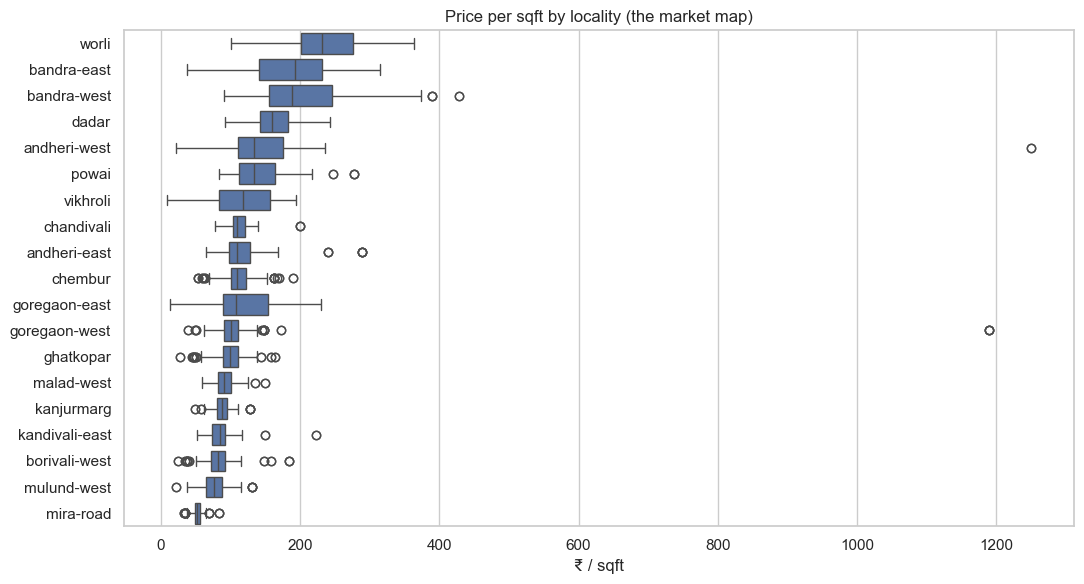

In [25]:
df['ppsf'] = df['rent'] / df['carpet_area']   # EDA ONLY (not a model feature)
loc_col = 'locality' if 'locality' in df.columns else None
if loc_col:
    order = df.groupby('locality')['ppsf'].median().sort_values(ascending=False).index
    plt.figure(figsize=(11,6))
    sns.boxplot(data=df, y='locality', x='ppsf', order=order)
    plt.title('Price per sqft by locality (the market map)'); plt.xlabel('₹ / sqft'); plt.ylabel('')
    plt.tight_layout(); plt.show()

In [27]:
ppsf_by_loc = df.groupby('locality')['ppsf'].median().sort_values(ascending=False)
print(ppsf_by_loc.round(0))
print(f"\nPremium/affordable ratio: {ppsf_by_loc.max()/ppsf_by_loc.min():.1f}x")

locality
worli             231.0
bandra-east       192.0
bandra-west       189.0
dadar             160.0
andheri-west      133.0
powai             133.0
vikhroli          118.0
chandivali        110.0
andheri-east      109.0
chembur           109.0
goregaon-east     108.0
goregaon-west     100.0
ghatkopar          99.0
malad-west         90.0
kanjurmarg         88.0
kandivali-east     84.0
borivali-west      82.0
mulund-west        76.0
mira-road          51.0
Name: ppsf, dtype: float64

Premium/affordable ratio: 4.5x


**Insight — the Mumbai rental market map:**

- **Clear locality hierarchy.** Median ₹/sqft ranks Worli, Bandra-East, and Bandra-West at the top (the premium South/Central belt) and Mira-Road, Mulund-West, and Borivali-West at the bottom (far suburbs). The top-to-bottom gap is roughly **2x+**, confirming location is a first-order driver of rent — not a minor adjustment.

- **Within-locality spread varies.** Premium areas like Worli and Bandra-West show *wide* boxes (high price variability — a mix of luxury and modest stock), while suburbs like Chembur and Mira-Road have *narrow* boxes (homogeneous, predictable pricing). Practically: in wide-spread localities, price is driven strongly by *other* features (area, furnishing, floor), so locality alone under-explains rent there — which justifies a multi-feature model over a location-only rule.

- **Luxury tail.** Bandra-West, Powai, and Andheri-East carry far-right outliers — genuine ultra-premium listings the model must accommodate, not data errors.

- **Consulting angle.** This is the market map a co-living operator or relocating tenant would use: moving outward from the Worli/Bandra belt yields large per-sqft savings, and narrow-box suburbs offer pricing certainty while wide-box premium areas leave room to negotiate.

* most premium = ₹231/sqft (Worli), most affordable = ₹51/sqft (Mira-Road), ratio = 4.5x.